# Data loading

In [ ]:
import sqlite3
import pandas as pd

In [ ]:
# Replace 'your_database.db' with the actual path to your file
db_path = 'database_5fish.db'

try:
    # This creates a connection object
    conn = sqlite3.connect(db_path)
    print(f"Successfully connected to {db_path}")
except sqlite3.Error as e:
    print(f"An error occurred: {e}")
    # Handle the error, e.g., exit or raise

Successfully connected to database_5fish.db


In [ ]:
# Create a Cursor object to execute SQL queries
cursor = conn.cursor()

# SQL query to get a list of all table names
tables_query = "SELECT name FROM sqlite_master WHERE type='table';"

# Execute the query and fetch all results
cursor.execute(tables_query)
table_names = [table[0] for table in cursor.fetchall()]

print("Tables found in the database:")
print(table_names)

Tables found in the database:
['AlternateLanguageName', 'AlternateLocationName', 'CheckedFiles', 'DblBibles', 'DblVolumes', 'DblBibleVolumes', 'LanguageScripts', 'DbpLanguages', 'DbpVersions', 'DbpBooks', 'DbpAudioLocations', 'DbpVolumes', 'DbpFonts', 'FeedProcessed', 'FeedType', 'Formats', 'ISOList', 'JfComponentDetails', 'JfComponentHierarchy', 'JfComponentRefIDs', 'JfComponents', 'JfLanguageNames', 'JfLanguages', 'JfMediaComponentsLanguages', 'Languages', 'LanguagesPrograms', 'Location', 'LocationLanguages', 'LocationType', 'MajorLanguages', 'ProgramType', 'Copyrights', 'ProgramFormats', 'Programs', 'ProgramSets', 'ProgramStates', 'Properties', 'ScriptVersion', 'TrackImage', 'TrackScriptLanguage', 'TrackTitle', 'Tracks', 'Video', 'android_metadata', 'PlaylistPrograms', 'Playlists', 'RelatedLocation', 'StringText', 'Organizations', 'Media', 'VernacularUiLanguageNames']


In [ ]:
import sqlite3
import pandas as pd

# 1. Define the file path and the table name
DB_PATH = 'database_5fish.db'  # <-- Change this to your actual file path
TABLE_NAME = 'view_iso_languages'

conn = sqlite3.connect(DB_PATH)
sql_query = f"SELECT * FROM {TABLE_NAME}"
TABLE_NAME = 'view_iso_languages'
df_isoLang = pd.read_sql_query(sql_query, conn)
TABLE_NAME = 'Languages'
sql_query = f"SELECT * FROM {TABLE_NAME}"
df_languages = pd.read_sql_query(sql_query, conn)
    # 4. Use pandas to read the SQL query results directly into a DataFrame
conn.close()

In [ ]:
df_isoLang.to_csv("df_isoLang.csv", index=False)

# Load Language List

In [ ]:
import pandas as pd
df_isoLang=pd.read_csv("df_isoLang.csv")

In [ ]:
df_isoLang.head()

,grn_language_id,iso_code
0,1,amh
1,4,arn
2,5,hyw
3,6,nhg
4,7,ayr


# Process Audio Files

In [ ]:
# convert first 100 rows of languages to audio files and hold as numpy array
# numpy arrays with float32 dtype 16kHz sampling

import os
import requests
import soundfile as sf
import torchaudio
import torch
import pandas as pd
from tqdm import tqdm

# take only the first 100 rows
df_sample = df_isoLang.iloc[:100].copy()

def fetch_and_process_audio(grn_language_id):
    url = f"https://media.globalrecordings.net/GOKit_MP3/sample-{grn_language_id}.mp3"
    filename = f"temp_{grn_language_id}.mp3"

    try:
        # download file
        r = requests.get(url, stream=True, timeout=20)
        if r.status_code != 200:
            return None
        with open(filename, "wb") as f:
            for chunk in r.iter_content(1024):
                f.write(chunk)

        # load with torchaudio (works with mp3)
        speech, sr = torchaudio.load(filename)

        # resample if needed
        if sr != 16000:
            speech = torchaudio.functional.resample(speech, sr, 16000)

        # convert to mono + numpy float32
        speech = speech.mean(dim=0)
        arr = speech.numpy().astype("float32")

        return arr
    except Exception as e:
        print(f"Error with {grn_language_id}: {e}")
        return None
    finally:
        if os.path.exists(filename):
            os.remove(filename)

# process in batches of 10 (but here only up to 100 total)
batch_size = 100
all_batches = []

for start in range(0, len(df_sample), batch_size):
    end = start + batch_size
    batch = df_sample.iloc[start:end].copy()

    audio_arrays = []
    for grn_id in tqdm(batch["grn_language_id"], desc=f"Batch {start//batch_size+1}"):
        arr = fetch_and_process_audio(grn_id)
        audio_arrays.append(arr)

    batch["audio_array"] = audio_arrays
    batch = batch.dropna(subset=["audio_array"])  # drop failed downloads

    all_batches.append(batch)

    del batch, audio_arrays

# final DataFrame with first 500 rows processed
df_audio_100 = pd.concat(all_batches, ignore_index=True)

print(df_audio_100.head())
print(f"Final dataset size: {len(df_audio_100)} rows")


Batch 1:   0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audi

   grn_language_id iso_code                                        audio_array
0                1      amh  [0.0010206132, 0.00047741047, -0.004935436, -0...
1                4      arn  [0.00024253162, 0.0002770615, 0.00015907771, 1...
2                5      hyw  [0.0017978126, 0.002636004, 0.002445325, 0.001...
3                6      nhg  [0.003604147, 0.007431329, 0.008929032, 0.0090...
4                7      ayr  [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
Final dataset size: 100 rows


# Saving and Loading Audio-CSV

Not very necessary for now

In [ ]:
#saving the df_audio_100 into csv
df_to_save = df_audio_100.copy()

# convert numpy arrays to strings
df_to_save["audio_array"] = df_to_save["audio_array"].apply(lambda x: x.tolist())

# save to CSV
df_to_save.to_csv("df_audio_100.csv", index=False)

In [ ]:
# loading csv audio data into arrays and df
import ast
import numpy as np

# read CSV
df_loaded = pd.read_csv("df_audio_100.csv")

# convert string → list → numpy array (float32)
df_loaded["audio_array"] = df_loaded["audio_array"].apply(
    lambda x: np.array(ast.literal_eval(x), dtype="float32")
)

print(type(df_loaded["audio_array"].iloc[0]))   # <class 'numpy.ndarray'>

<class 'numpy.ndarray'>


In [ ]:
# import h5py

# with h5py.File("audio_store.h5", "a") as f:
#     for i, row in df_audio_100.iterrows():
#         f.create_dataset(str(row["grn_language_id"]), data=row["audio_array"], compression="gzip")

In [ ]:
df_audio_100

,grn_language_id,iso_code,audio_array
0,1,amh,"[0.0010206132, 0.00047741047, -0.004935436, -0..."
1,4,arn,"[0.00024253162, 0.0002770615, 0.00015907771, 1..."
2,5,hyw,"[0.0017978126, 0.002636004, 0.002445325, 0.001..."
3,6,nhg,"[0.003604147, 0.007431329, 0.008929032, 0.0090..."
4,7,ayr,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...
95,130,ndc,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
96,131,tur,"[-0.00026998058, -0.00015298472, -0.0001375784..."
97,132,mal,"[0.00036170543, 0.00095701305, -0.004928746, -..."
98,133,ces,"[-2.0221954e-32, -2.0221954e-32, -2.0221954e-3..."


In [ ]:
df_audio_500.to_pickle("df_audio_500.pkl")

In [ ]:
import os
import requests
import torchaudio
import pandas as pd
from tqdm import tqdm

# --- same helper function as before ---
def fetch_and_process_audio(grn_language_id):
    url = f"https://media.globalrecordings.net/GOKit_MP3/sample-{grn_language_id}.mp3"
    filename = f"temp_{grn_language_id}.mp3"

    try:
        r = requests.get(url, stream=True, timeout=20)
        if r.status_code != 200:
            return None
        with open(filename, "wb") as f:
            for chunk in r.iter_content(1024):
                f.write(chunk)

        speech, sr = torchaudio.load(filename)

        if sr != 16000:
            speech = torchaudio.functional.resample(speech, sr, 16000)

        speech = speech.mean(dim=0)
        arr = speech.numpy().astype("float32")

        return arr
    except Exception as e:
        print(f"Error with {grn_language_id}: {e}")
        return None
    finally:
        if os.path.exists(filename):
            os.remove(filename)

# --- Step 1: load existing pickle if available ---
pickle_file = "df_audio_500.pkl"
if os.path.exists(pickle_file):
    df_audio = pd.read_pickle(pickle_file)
else:
    df_audio = pd.DataFrame(columns=["grn_language_id", "iso_code", "audio_array"])

# --- Step 2: process the second 100 rows (rows 100–200) ---
df_sample = df_isoLang.iloc[500:1000].copy()

audio_arrays = []
for grn_id in tqdm(df_sample["grn_language_id"], desc="Processing 500–1000"):
    arr = fetch_and_process_audio(grn_id)
    audio_arrays.append(arr)

df_sample["audio_array"] = audio_arrays
df_sample = df_sample.dropna(subset=["audio_array"])

# --- Step 3: append to existing data ---
df_audio = pd.concat([df_audio, df_sample], ignore_index=True)

# --- Step 4: save back to pickle ---
df_audio.to_pickle(pickle_file)

print(f"Pickle updated: {pickle_file}")
print(f"Total rows saved so far: {len(df_audio)}")


Processing 100–200:   0%|          | 0/100 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/p

Pickle updated: df_audio_batches.pkl
Total rows saved so far: 96


# Fine Tuning - Attempt 1

Working with df_audio_100

In [ ]:
df_audio_100

,grn_language_id,iso_code,audio_array
0,1,amh,"[0.0010206132, 0.00047741047, -0.004935436, -0..."
1,4,arn,"[0.00024253162, 0.0002770615, 0.00015907771, 1..."
2,5,hyw,"[0.0017978126, 0.002636004, 0.002445325, 0.001..."
3,6,nhg,"[0.003604147, 0.007431329, 0.008929032, 0.0090..."
4,7,ayr,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...
95,130,ndc,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
96,131,tur,"[-0.00026998058, -0.00015298472, -0.0001375784..."
97,132,mal,"[0.00036170543, 0.00095701305, -0.004928746, -..."
98,133,ces,"[-2.0221954e-32, -2.0221954e-32, -2.0221954e-3..."


## Install modules & Import

In [ ]:
!pip install transformers datasets accelerate

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from datasets import Dataset
from transformers import (
    AutoFeatureExtractor,
    AutoModelForAudioClassification,
    TrainingArguments,
    Trainer,
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.9/73.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.6/503.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.8/241.8 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.4/224.4 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.6/355.6 kB 36.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/torch_xla/experimental/gru.py:113: SyntaxWarning: invalid escape sequence '\_'
  * **h_n**: tensor of shape :math:`(D * \text{num\_layers}, H_{out})` or
/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:82: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


## Load Data

Transforming our dataset into a hugging face dataset

In [ ]:
dataset = Dataset.from_pandas(df_audio_100)

## Load Model + feature extractor

In [ ]:
model_id = "facebook/mms-lid-4017"

feature_extractor = AutoFeatureExtractor.from_pretrained(model_id)
model = AutoModelForAudioClassification.from_pretrained(model_id)

# Build label mappings
unique_labels = df_audio_100["iso_code"].unique()
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}

# Replace classifier head
num_labels = len(unique_labels)
model.classifier = nn.Linear(model.classifier.in_features, num_labels)

# Update config
model.config.num_labels = num_labels
model.config.label2id = label2id
model.config.id2label = id2label

# Freeze backbone (train only classifier head)
for param in model.wav2vec2.parameters():
    param.requires_grad = False

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.88G [00:00<?, ?B/s]

## Encode Labels -

Preprocess dataset

In [ ]:
def preprocess(example):
    audio = example["audio_array"]
    # Make sure tensors are on CPU
    inputs = feature_extractor(audio, sampling_rate=16_000, return_tensors="pt")
    example["input_values"] = inputs.input_values[0].cpu()  # ensure CPU
    example["labels"] = label2id[example["iso_code"]]
    return example

# Use batched=False so each example is processed individually
dataset = dataset.map(preprocess, batched=False)

# Hugging Face Trainer expects torch tensors
dataset.set_format(type="torch", columns=["input_values", "labels"])

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

## Hyperparameters Setup

In [ ]:
# !pip install cloud-tpu-client torch-xla
import torch, torch_xla, transformers

In [ ]:
training_args = TrainingArguments(
    output_dir="./mms_lid_finetuned",
    per_device_train_batch_size=1,
    bf16=True,   # TPU only
    num_train_epochs=5,
    logging_steps=5,
    save_strategy="epoch",
    report_to="none",
)
def compute_metrics(pred):
    preds = np.argmax(pred.predictions, axis=1)
    acc = (preds == pred.label_ids).mean()
    return {"accuracy": acc}

import torch_xla.core.xla_model as xm
device = xm.xla_device()
model.to(device)

/tmp/ipython-input-2384062894.py:16: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()


Wav2Vec2ForSequenceClassification(
  (wav2vec2): Wav2Vec2Model(
    (feature_extractor): Wav2Vec2FeatureEncoder(
      (conv_layers): ModuleList(
        (0): Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (1-4): 4 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
        (5-6): 2 x Wav2Vec2LayerNormConvLayer(
          (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation): GELUActivation()
        )
      )
    )
    (feature_projection): Wav2Vec2FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=

In [ ]:
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=1e-4,
    fused=False  # <--- must be False for TPU/XLA
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    eval_dataset=dataset,
    tokenizer=feature_extractor,
    optimizers=(optimizer, None)  # (optimizer, scheduler)
)

/tmp/ipython-input-1979991460.py:9: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
trainer.train()

Step,Training Loss


KeyboardInterrupt: 

In [ ]:
trainer.train()

Step,Training Loss
5,5.364100


OutOfMemoryError: CUDA out of memory. Tried to allocate 102.00 MiB. GPU 0 has a total capacity of 39.56 GiB of which 6.88 MiB is free. Process 72713 has 39.54 GiB memory in use. Of the allocated memory 37.16 GiB is allocated by PyTorch, and 1.87 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

# Fine Tuning - Attempt 2

In [ ]:
!pip install datasets;

In [ ]:
import torch
import numpy as np
from datasets import Dataset
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification, Trainer, TrainingArguments

/usr/local/lib/python3.12/dist-packages/torch_xla/experimental/gru.py:113: SyntaxWarning: invalid escape sequence '\_'
  * **h_n**: tensor of shape :math:`(D * \text{num\_layers}, H_{out})` or
/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:82: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
# Step 1: Prepare dataset
# -------------------------------
# df_audio_100 has columns: 'iso_code', 'audio_array'
df_audio_100 = df_audio_100.reset_index(drop=True)

# Convert df to Hugging Face Dataset
dataset = Dataset.from_pandas(df_audio_100)

# Map iso_code to label ids
unique_labels = dataset.unique('iso_code')
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}
num_labels = len(unique_labels)

In [ ]:
model_id = "facebook/mms-lid-4017"
feature_extractor = AutoFeatureExtractor.from_pretrained(model_id)

def preprocess(example):
    audio = example["audio_array"]
    # Convert numpy array to input_values tensor
    inputs = feature_extractor(audio, sampling_rate=16000, return_tensors="pt")
    example["input_values"] = inputs.input_values[0]  # shape: [seq_len]
    example["labels"] = label2id[example["iso_code"]]
    return example

dataset = dataset.map(preprocess)
# Keep only necessary columns
dataset = dataset.remove_columns(["iso_code", "audio_array"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [ ]:
# Step 3: Load model
# -------------------------------
model = AutoModelForAudioClassification.from_pretrained(
    model_id,
    num_labels=num_labels,
    ignore_mismatched_sizes=True  # allows resizing classifier head
)
model.config.label2id = label2id
model.config.id2label = id2label

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.88G [00:00<?, ?B/s]

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/mms-lid-4017 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([4017]) in the checkpoint and torch.Size([100]) in the model instantiated
- classifier.weight: found shape torch.Size([4017, 1024]) in the checkpoint and torch.Size([100, 1024]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# -------------------------------
# Step 4: Define training args
# -------------------------------
training_args = TrainingArguments(
    output_dir="./mms_lid_finetuned_fast",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    num_train_epochs=2,       # small for fast testing
    logging_steps=1,
    save_strategy="no",       # avoid saving checkpoints to save time
    report_to="none",
    fp16=False,               # CPU/TPU: disable
    dataloader_pin_memory=False
)

In [ ]:
# Step 5: Optimizer for TPU/CPU
# -------------------------------
from torch.optim import AdamW

import torch_xla.core.xla_model as xm

# 1️⃣ Move model to TPU
device = xm.xla_device()
model.to(device)

# 2️⃣ Create optimizer AFTER moving the model
from torch.optim import AdamW


optimizer = AdamW(model.parameters(), lr=1e-4, fused=False)


/tmp/ipython-input-63787126.py:8: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()


In [ ]:
# Step 6: Initialize Trainer
# -------------------------------
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    eval_dataset=dataset,
    optimizers=(optimizer, None),
    preprocess_logits_for_metrics=None  # optional
)

In [ ]:
trainer.train()

RuntimeError: Compilation failure: Aborting compilation early because it's unlikely to have enough device memory. Requires 368.64G, has 29.68G available. If more detailed logging is desired, set --xla_tpu_impure_oom_fast_exit_threshold=-1

# Fine Tuning - Attempt 3

Precompute embeddings


In [ ]:
import torch
import numpy as np
from datasets import Dataset
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification, Trainer, TrainingArguments


In [ ]:
# df_audio_100 has 'iso_code' and 'audio_array' columns
df_audio_100 = df_audio_100.reset_index(drop=True)

dataset = Dataset.from_pandas(df_audio_100)

# Map iso_code to label ids
unique_labels = dataset.unique('iso_code')
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}
num_labels = len(unique_labels)


In [ ]:
model_id = "facebook/mms-lid-4017"

feature_extractor = AutoFeatureExtractor.from_pretrained(model_id)

# Load the base model in eval mode and freeze it
base_model = AutoModelForAudioClassification.from_pretrained(model_id)
base_model.eval()
for param in base_model.parameters():
    param.requires_grad = False  # freeze everything


In [ ]:
# This step takes 54 minutes Colab Pro - v6e-1 TPU
from tqdm import tqdm
import torch
import numpy as np

embeddings = []
labels = []

for example in tqdm(dataset, desc="Computing embeddings"):
    audio = example["audio_array"]
    # Convert to tensor
    input_values = feature_extractor(audio, sampling_rate=16000, return_tensors="pt").input_values
    with torch.no_grad():
        # Get hidden state from the base model (usually the last hidden layer)
        hidden = base_model.base_model(input_values).last_hidden_state
        # Pool across time dimension (mean pooling)
        pooled = hidden.mean(dim=1)
        embeddings.append(pooled.squeeze(0).numpy())  # convert to numpy
    labels.append(label2id[example["iso_code"]])

# Convert lists to tensors
X = torch.tensor(np.stack(embeddings), dtype=torch.float32)
y = torch.tensor(labels, dtype=torch.long)


Computing embeddings: 100%|██████████| 100/100 [54:01<00:00, 32.41s/it]


In [ ]:
## Define a small Classifier:

import torch.nn as nn

class SimpleClassifier(nn.Module):
    def __init__(self, input_dim, num_labels):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_labels)

    def forward(self, x):
        return self.linear(x)

classifier = SimpleClassifier(input_dim=X.shape[1], num_labels=num_labels)

In [ ]:
# re initialize each time you want to reset the model - don't run this if you want to see incremental changes on the classifier model

# Reinitialize model each time you want a fresh start
classifier = SimpleClassifier(input_dim=X.shape[1], num_labels=num_labels)
classifier.to(device)

# Reinitialize optimizer too (important, because it stores momentum terms, etc.)
optimizer = AdamW(classifier.parameters(), lr=1e-3)

Epoch 1, Loss: 4.7888
Epoch 2, Loss: 2.0101
Epoch 3, Loss: 0.4885
Epoch 4, Loss: 0.1579
Epoch 5, Loss: 0.0888
Epoch 6, Loss: 0.0589
Epoch 7, Loss: 0.0464
Epoch 8, Loss: 0.0372
Epoch 9, Loss: 0.0306
Epoch 10, Loss: 0.0263
Epoch 11, Loss: 0.0226
Epoch 12, Loss: 0.0198
Epoch 13, Loss: 0.0177
Epoch 14, Loss: 0.0158
Epoch 15, Loss: 0.0141
Epoch 16, Loss: 0.0128
Epoch 17, Loss: 0.0117
Epoch 18, Loss: 0.0107
Epoch 19, Loss: 0.0098
Epoch 20, Loss: 0.0091
Epoch 21, Loss: 0.0084
Epoch 22, Loss: 0.0078
Epoch 23, Loss: 0.0073
Epoch 24, Loss: 0.0069
Epoch 25, Loss: 0.0065
Epoch 26, Loss: 0.0061
Epoch 27, Loss: 0.0057
Epoch 28, Loss: 0.0054
Epoch 29, Loss: 0.0051
Epoch 30, Loss: 0.0048
Epoch 31, Loss: 0.0046
Epoch 32, Loss: 0.0044
Epoch 33, Loss: 0.0042
Epoch 34, Loss: 0.0040
Epoch 35, Loss: 0.0038
Epoch 36, Loss: 0.0036
Epoch 37, Loss: 0.0035
Epoch 38, Loss: 0.0033
Epoch 39, Loss: 0.0032
Epoch 40, Loss: 0.0031
Epoch 41, Loss: 0.0030
Epoch 42, Loss: 0.0028
Epoch 43, Loss: 0.0027
Epoch 44, Loss: 0.00

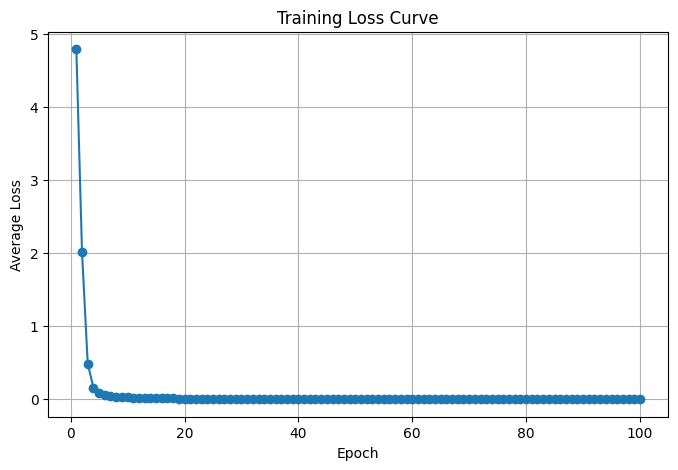

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW

# Assuming X, y, and classifier are already defined
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

optimizer = AdamW(classifier.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

device = torch.device("cpu")  # or GPU if available
classifier.to(device)

# Training
num_epochs = 100
losses = []

for epoch in range(num_epochs):
    classifier.train()
    total_loss = 0
    for batch_X, batch_y in dataloader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        logits = classifier(batch_X)
        loss = loss_fn(logits, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

# Plot loss curve
plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

In [ ]:
import torch
import numpy as np

# Build reverse mapping
id2label = {v: k for k, v in label2id.items()}

def predict_language(audio_array):
    # Step 1: Extract embedding with the frozen base model
    input_values = feature_extractor(audio_array, sampling_rate=16000, return_tensors="pt").input_values
    with torch.no_grad():
        hidden = base_model.base_model(input_values).last_hidden_state
        pooled = hidden.mean(dim=1)  # [1, hidden_dim]
        emb = pooled.numpy()

    # Step 2: Convert to tensor for classifier
    emb_tensor = torch.tensor(emb, dtype=torch.float32)

    # Step 3: Get classifier logits
    classifier.eval()
    with torch.no_grad():
        logits = classifier(emb_tensor)

    # Step 4: Softmax → probabilities
    probs = torch.nn.functional.softmax(logits, dim=-1)

    # Step 5: Get predicted label
    pred_id = torch.argmax(probs, dim=-1).item()
    pred_label = id2label[pred_id]

    return pred_label, probs.numpy()

## Load audio for prediction

In [ ]:
import torchaudio

# Load audio file
waveform, sr = torchaudio.load("Day 1_ Greetings.mp3")  # waveform shape: [channels, samples]

# Convert to mono if stereo
if waveform.shape[0] > 1:
    waveform = waveform.mean(dim=0, keepdim=True)

# Resample if not 16kHz
if sr != 16000:
    resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=16000)
    waveform = resampler(waveform)

# Convert to numpy float32
audio_array = waveform.squeeze().numpy().astype("float32")

# Now pass into your predict function
pred_lang, probs = predict_language(audio_array)
print("Predicted language:", pred_lang)

/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:88: UserWarning: torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be r

Predicted language: kor


## Top 5 predictions from Original Model

In [ ]:
import torch
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

# Load feature extractor and model
model_name = "facebook/mms-lid-4017"
feature_extractor = AutoFeatureExtractor.from_pretrained(model_name)
model = AutoModelForAudioClassification.from_pretrained(model_name)

# audio_array: your preprocessed numpy array (16kHz, float32)
inputs = feature_extractor(audio_array, sampling_rate=16000, return_tensors="pt")

# Get logits
with torch.no_grad():
    logits = model(**inputs).logits

# Convert to probabilities
probs = torch.softmax(logits, dim=-1)[0]

# Top 5 predictions
top5_prob, top5_idx = torch.topk(probs, k=5)
id2label = model.config.id2label
top5_languages = [id2label[idx.item()] for idx in top5_idx]

# Display
for lang, prob in zip(top5_languages, top5_prob):
    print(f"{lang}: {prob.item():.4f}")


kor: 0.9995
jpn: 0.0000
las: 0.0000
cwa: 0.0000
knc: 0.0000


## Top 5 predictions from new classifier

In [ ]:
import torch
import numpy as np

# id2label mapping already defined
# label2id: your original label → index dict
id2label = {v: k for k, v in label2id.items()}

def predict_top5_languages(audio_array, top_k=5):
    # Step 1: Extract embedding with the frozen base model
    input_values = feature_extractor(audio_array, sampling_rate=16000, return_tensors="pt").input_values
    with torch.no_grad():
        hidden = base_model.base_model(input_values).last_hidden_state
        pooled = hidden.mean(dim=1)  # [1, hidden_dim]
        emb = pooled.numpy()

    # Step 2: Convert to tensor for classifier
    emb_tensor = torch.tensor(emb, dtype=torch.float32)

    # Step 3: Get classifier logits
    classifier.eval()
    with torch.no_grad():
        logits = classifier(emb_tensor)

    # Step 4: Softmax → probabilities
    probs = torch.nn.functional.softmax(logits, dim=-1).squeeze()  # [num_classes]

    # Step 5: Get top K predictions
    top_probs, top_indices = torch.topk(probs, k=top_k)
    top_labels = [id2label[idx.item()] for idx in top_indices]

    # Return as a list of tuples (label, probability)
    return list(zip(top_labels, top_probs.numpy()))

# Example usage:
top5 = predict_top5_languages(audio_array)
for label, prob in top5:
    print(f"{label}: {prob:.4f}")


kor: 0.9988
jpn: 0.0003
ale: 0.0000
mar: 0.0000
yue: 0.0000


## All possible predictions from Classifier

In [ ]:
import torch
import numpy as np

# id2label mapping already defined
id2label = {v: k for k, v in label2id.items()}

def predict_all_languages(audio_array):
    # Step 1: Extract embedding with the frozen base model
    input_values = feature_extractor(audio_array, sampling_rate=16000, return_tensors="pt").input_values
    with torch.no_grad():
        hidden = base_model.base_model(input_values).last_hidden_state
        pooled = hidden.mean(dim=1)  # [1, hidden_dim]
        emb = pooled.numpy()

    # Step 2: Convert to tensor for classifier
    emb_tensor = torch.tensor(emb, dtype=torch.float32)

    # Step 3: Get classifier logits
    classifier.eval()
    with torch.no_grad():
        logits = classifier(emb_tensor)

    # Step 4: Softmax → probabilities
    probs = torch.nn.functional.softmax(logits, dim=-1).squeeze()  # [num_classes]

    # Step 5: Map all predictions
    all_labels = [id2label[idx] for idx in range(len(probs))]
    all_probs = probs.numpy()

    # Step 6: Sort by probability descending
    sorted_indices = np.argsort(-all_probs)
    all_labels_sorted = [all_labels[i] for i in sorted_indices]
    all_probs_sorted = all_probs[sorted_indices]

    return list(zip(all_labels_sorted, all_probs_sorted))

# Example usage:
all_predictions = predict_all_languages(audio_array)
for label, prob in all_predictions:
    print(f"{label}: {prob:.4f}")


tsz: 0.9920
jiv: 0.0005
hmd: 0.0003
hop: 0.0003
yaq: 0.0003
zul: 0.0002
alz: 0.0002
nkw: 0.0002
kam: 0.0002
hdn: 0.0002
ind: 0.0002
quh: 0.0002
pow: 0.0002
ces: 0.0002
yum: 0.0002
bum: 0.0002
suk: 0.0001
shn: 0.0001
cdo: 0.0001
ktu: 0.0001
ote: 0.0001
mau: 0.0001
nav: 0.0001
zmp: 0.0001
tli: 0.0001
zoc: 0.0001
hch: 0.0001
hat: 0.0001
ndc: 0.0001
poi: 0.0001
shp: 0.0001
nld: 0.0001
azz: 0.0001
spy: 0.0001
bxg: 0.0001
tpl: 0.0001
qug: 0.0001
nhg: 0.0001
sgc: 0.0001
ayr: 0.0001
tee: 0.0001
yua: 0.0001
ale: 0.0001
tel: 0.0001
deu: 0.0001
quc: 0.0001
tsi: 0.0001
coc: 0.0001
pbs: 0.0001
caa: 0.0001
snv: 0.0001
kek: 0.0001
maz: 0.0001
ita: 0.0000
zav: 0.0000
mos: 0.0000
som: 0.0000
aii: 0.0000
wbm: 0.0000
tso: 0.0000
udu: 0.0000
run: 0.0000
tsc: 0.0000
lin: 0.0000
tur: 0.0000
mal: 0.0000
bam: 0.0000
tgl: 0.0000
tfn: 0.0000
ilo: 0.0000
zai: 0.0000
pol: 0.0000
ydd: 0.0000
arn: 0.0000
kor: 0.0000
kik: 0.0000
zaa: 0.0000
mar: 0.0000
nhw: 0.0000
gbr: 0.0000
jpn: 0.0000
urd: 0.0000
amh: 0.0000
cmn:

In [ ]:
len(all_predictions)

100